Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │         125,450 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,394 (509.35 KB)

 Trainable params: 130,394 (509.35 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9538 - loss: 0.1549
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9826 - loss: 0.0577
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9877 - loss: 0.0400
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9909 - loss: 0.0288
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9931 - loss: 0.0208
Test loss: 0.048382002860307693
Test accuracy: 0.9854000210762024
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


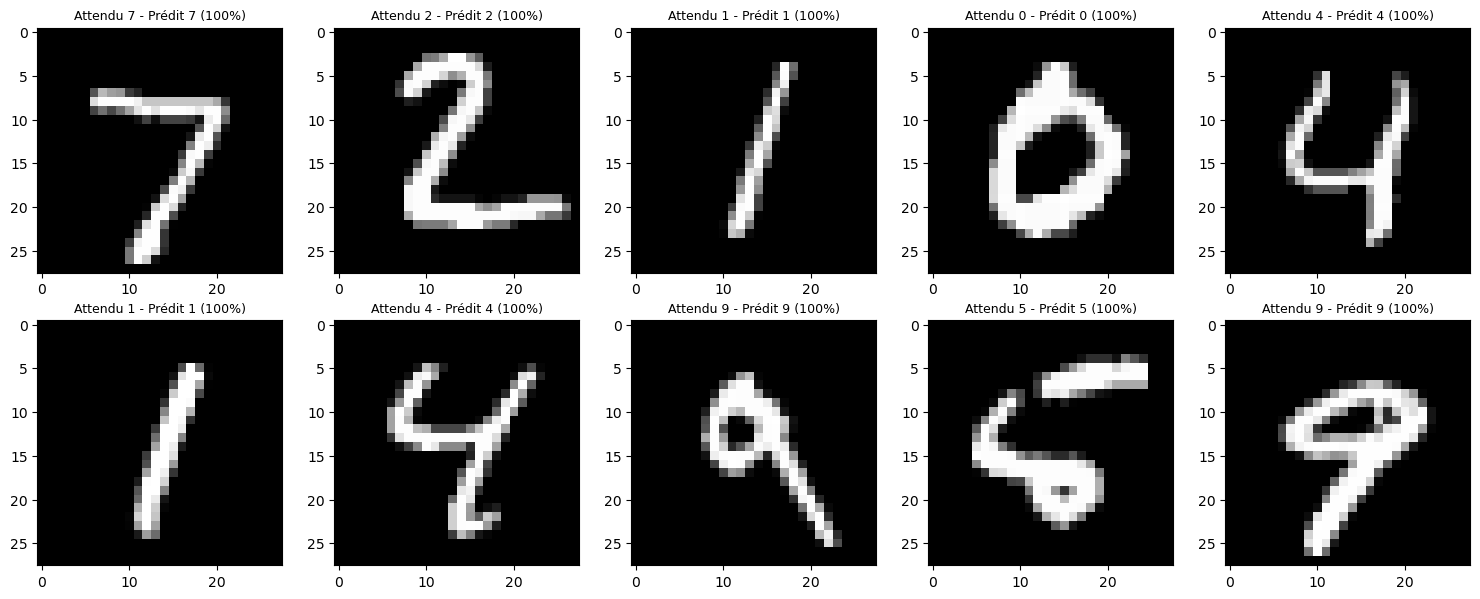

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
(X_train_data,Y_train_data),(X_test_data,Y_test_data) = mnist.load_data()
N = X_train_data.shape[0]

239
X_train = np.reshape(X_train_data, (N,28,28,1))
X_test = np.reshape(X_test_data, (X_test_data.shape[0],28,28,1))
X_train = X_train/255

X_test = X_test/255
Y_train = to_categorical(Y_train_data, num_classes=10)
Y_test = to_categorical(Y_test_data, num_classes=10)

modele = Sequential()
modele.add(Input(shape=(28,28,1)))

modele.add(Conv2D(32, kernel_size=3, padding='same', activation='relu'))

modele.add(Conv2D(16, kernel_size=3, padding='same', activation='relu'))

modele.add(Flatten())

modele.add(Dense(10, activation='softmax'))

modele.compile(loss='categorical_crossentropy',
optimizer='adam',
metrics=['accuracy'])
print(modele.summary())

modele.fit(X_train, Y_train, batch_size=32, epochs=5)

score = modele.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

predictions = modele.predict(X_test)


plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_data[i], cmap='gray')
    
    predicted_label = np.argmax(predictions[i])
    confidence = np.max(predictions[i]) * 100
    true_label = Y_test_data[i]
    
    plt.title(f"Attendu {true_label} - Prédit {predicted_label} ({confidence:.0f}%)", fontsize=9)
    plt.axis('on')

plt.tight_layout()
plt.show()